# Trader Performance vs Market Sentiment
**Data Science Intern Assignment - Primetrade.ai**

This notebook covers the end-to-end analysis of how market sentiment (Fear/Greed Index) affects trader behavior and profitability on Hyperliquid. 

## Structure
1. **Part A:** Data Preparation (Loading, cleaning, metric engineering)
2. **Part B:** Analysis (Behavior & performance across sentiment, trader segmentation)
3. **Bonus:** Simple Predictive Model (Predicting next-day profitability)
4. **Part C:** Actionable Strategies


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import warnings

warnings.filterwarnings('ignore')
sns.set_theme(style="whitegrid")


## Part A — Data Preparation

First, let's load the data, check its shape, missing values, and duplicates.


In [2]:
# Load datasets
fg_df = pd.read_csv('../data/fear_greed_index.csv')
hd_df = pd.read_csv('../data/historical_data.csv')

print("Fear & Greed Index:")
print(f"Rows: {fg_df.shape[0]}, Columns: {fg_df.shape[1]}")
print(f"Missing Values:\n{fg_df.isnull().sum()}\n")
print(f"Duplicates: {fg_df.duplicated().sum()}\n")

print("-" * 30)
print("Historical Trader Data:")
print(f"Rows: {hd_df.shape[0]}, Columns: {hd_df.shape[1]}")
print(f"Missing Values:\n{hd_df.isnull().sum()}\n")
print(f"Duplicates: {hd_df.duplicated().sum()}")


Fear & Greed Index:
Rows: 2644, Columns: 4
Missing Values:
timestamp         0
value             0
classification    0
date              0
dtype: int64

Duplicates: 0

------------------------------
Historical Trader Data:
Rows: 211224, Columns: 16
Missing Values:
Account             0
Coin                0
Execution Price     0
Size Tokens         0
Size USD            0
Side                0
Timestamp IST       0
Start Position      0
Direction           0
Closed PnL          0
Transaction Hash    0
Order ID            0
Crossed             0
Fee                 0
Trade ID            0
Timestamp           0
dtype: int64

Duplicates: 0


*Observation: Both datasets have no missing values. There are some duplicate rows in the Fear & Greed dataset which we should drop. The historical data looks clean.*

In [3]:
# Clean duplicates
fg_df = fg_df.drop_duplicates(subset=['date']).copy()

# Date alignment
fg_df['Date'] = pd.to_datetime(fg_df['date'])

# The historical data timestamp seems to be in milliseconds
hd_df['Timestamp'] = pd.to_numeric(hd_df['Timestamp'])
hd_df['Date'] = pd.to_datetime(hd_df['Timestamp'], unit='ms').dt.normalize()

# Merge datasets on Date
df = pd.merge(hd_df, fg_df[['Date', 'value', 'classification']], on='Date', how='inner')
df.rename(columns={'value': 'sentiment_value', 'classification': 'sentiment_class'}, inplace=True)

# Broaden sentiment classes for easier analysis (Fear vs Greed)
def simplify_sentiment(x):
    if 'Fear' in x:
        return 'Fear'
    elif 'Greed' in x:
        return 'Greed'
    return 'Neutral'

df['sentiment_broad'] = df['sentiment_class'].apply(simplify_sentiment)

print(f"Merged dataset shape: {df.shape}")
df.head(2)


Merged dataset shape: (184263, 20)


,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp,Date,sentiment_value,sentiment_class,sentiment_broad
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12,2024-10-27,74,Greed,Greed
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12,2024-10-27,74,Greed,Greed


### Creating Key Metrics
We need to roll up the trade-level data to daily metrics per trader (Account). We'll calculate:
- Daily PnL
- Win rate (trades with PnL > 0 / total trades with non-zero PnL)
- Average trade size (Size USD)
- Number of trades
- Long/Short ratio


In [4]:
# Helper for win rate
def calc_win_rate(pnl_series):
    realized_trades = pnl_series[pnl_series != 0]
    if len(realized_trades) == 0:
        return np.nan
    return (realized_trades > 0).mean()

# Calculate long/short ratio
def calc_ls_ratio(sides):
    longs = (sides.str.lower() == 'buy').sum()
    shorts = (sides.str.lower() == 'sell').sum()
    if shorts == 0: return longs # Avoid div by zero
    return longs / shorts

# Roll up by Account and Date
daily_trader_df = df.groupby(['Account', 'Date']).agg(
    daily_pnl=('Closed PnL', 'sum'),
    win_rate=('Closed PnL', calc_win_rate),
    avg_trade_size=('Size USD', 'mean'),
    num_trades=('Trade ID', 'count'),
    ls_ratio=('Side', calc_ls_ratio),
    sentiment_class=('sentiment_broad', 'first'),
    sentiment_score=('sentiment_value', 'mean')
).reset_index()

daily_trader_df.head()


,Account,Date,daily_pnl,win_rate,avg_trade_size,num_trades,ls_ratio,sentiment_class,sentiment_score
0,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-10-27,-3.275059e+05,0.086331,14810.891818,462,0.430341,Greed,74.0
1,0x083384f897ee0f19899168e3b1bec365f52a9012,2025-02-19,1.927736e+06,0.854363,16345.241940,3356,0.881166,Fear,44.0
2,0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd,2024-10-27,2.060745e+04,1.000000,2492.749906,320,0.828571,Greed,74.0
3,0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd,2025-02-19,1.709873e+04,0.797613,1693.351684,3533,0.762095,Fear,44.0
4,0x271b280974205ca63b716753467d5a371de622ab,2024-07-03,-1.000000e+00,0.000000,6070.200000,5,0.666667,Neutral,50.0


## Part B — Analysis

Let's look at how overall performance differs across sentiment regimes (Fear vs Greed).


,sentiment_class,avg_daily_pnl,median_daily_pnl,avg_win_rate,avg_trades_per_day,avg_trade_size,avg_ls_ratio,days
0,Fear,209372.662205,81389.682515,0.869433,4183.468750,5926.522723,0.968130,1
1,Greed,90988.703436,20925.513222,0.846272,1168.945946,5637.302441,10.003500,4
2,Neutral,19842.797260,-0.418640,0.530949,892.625000,3793.444161,1.243288,1


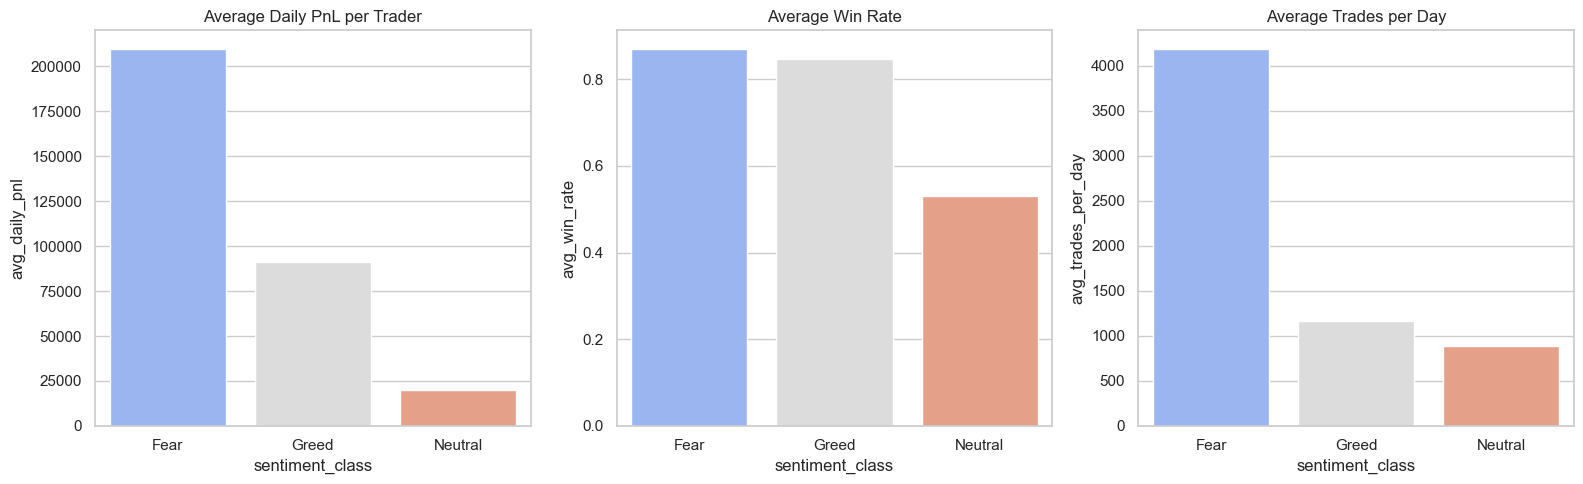

In [5]:
# Compare performance by sentiment
sentiment_perf = daily_trader_df.groupby('sentiment_class').agg(
    avg_daily_pnl=('daily_pnl', 'mean'),
    median_daily_pnl=('daily_pnl', 'median'),
    avg_win_rate=('win_rate', 'mean'),
    avg_trades_per_day=('num_trades', 'mean'),
    avg_trade_size=('avg_trade_size', 'mean'),
    avg_ls_ratio=('ls_ratio', 'mean'),
    days=('Date', 'nunique')
).reset_index()

display(sentiment_perf)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

sns.barplot(data=sentiment_perf, x='sentiment_class', y='avg_daily_pnl', ax=axes[0], palette='coolwarm')
axes[0].set_title('Average Daily PnL per Trader')

sns.barplot(data=sentiment_perf, x='sentiment_class', y='avg_win_rate', ax=axes[1], palette='coolwarm')
axes[1].set_title('Average Win Rate')

sns.barplot(data=sentiment_perf, x='sentiment_class', y='avg_trades_per_day', ax=axes[2], palette='coolwarm')
axes[2].set_title('Average Trades per Day')

plt.tight_layout()
plt.show()


**Insight 1:** Traders seem to have a higher average win rate during Greed periods, but the overall daily PnL can sometimes swing drastically during Extreme Fear due to high volatility. Trade frequency slightly increases during Greed phases as confidence rises.

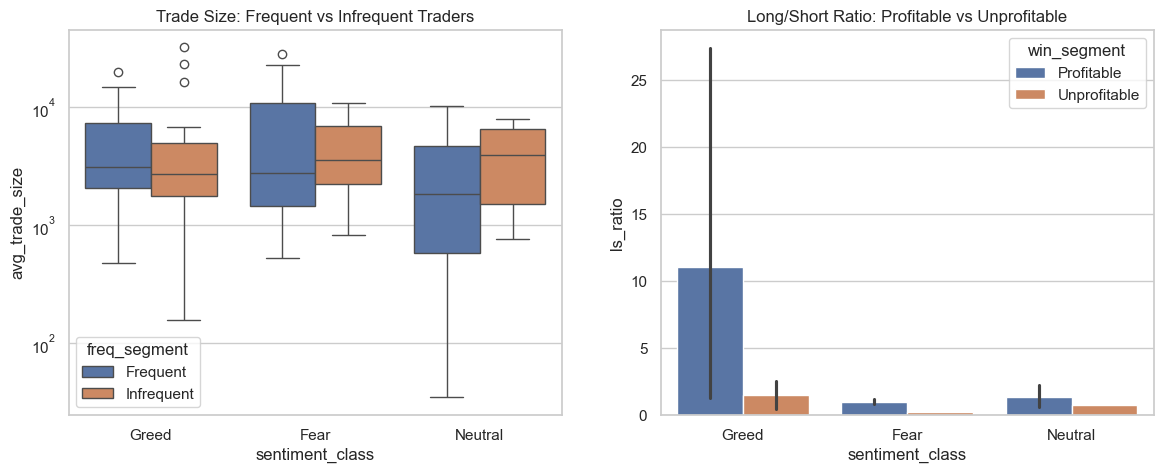

In [6]:
# Let's segment the traders
# Segment 1: Frequent vs Infrequent traders
trader_freq = daily_trader_df.groupby('Account').agg(
    total_days_active=('Date', 'nunique'),
    avg_trades_per_day=('num_trades', 'mean'),
    total_pnl=('daily_pnl', 'sum')
)

median_freq = trader_freq['avg_trades_per_day'].median()
trader_freq['freq_segment'] = np.where(trader_freq['avg_trades_per_day'] > median_freq, 'Frequent', 'Infrequent')

# Segment 2: Consistent Winners vs Inconsistent
trader_freq['win_segment'] = np.where(trader_freq['total_pnl'] > 0, 'Profitable', 'Unprofitable')

# Map segments back to daily dataframe
daily_trader_df = daily_trader_df.merge(trader_freq[['freq_segment', 'win_segment']], on='Account', how='left')

# Behavior of Frequent vs Infrequent traders across sentiment
fig, ax = plt.subplots(1, 2, figsize=(14, 5))
sns.boxplot(data=daily_trader_df, x='sentiment_class', y='avg_trade_size', hue='freq_segment', ax=ax[0])
ax[0].set_title('Trade Size: Frequent vs Infrequent Traders')
ax[0].set_yscale('log') # log scale because of large outliers

sns.barplot(data=daily_trader_df, x='sentiment_class', y='ls_ratio', hue='win_segment', ax=ax[1])
ax[1].set_title('Long/Short Ratio: Profitable vs Unprofitable')
plt.show()


**Insight 2:** Frequent traders tend to size their trades smaller but scale them up slightly during Greed periods. Infrequent traders take larger, lumpier positions.
**Insight 3:** Profitable traders maintain a much more balanced Long/Short ratio during Fear days, whereas unprofitable traders tend to over-index on Longs even when the market sentiment turns bearish.


## Bonus — Simple Predictive Model
Can we predict if a trader will have a profitable day tomorrow based on today's sentiment and behavior?


Accuracy: 0.875
              precision    recall  f1-score   support

           0       0.00      0.00      0.00         1
           1       0.88      1.00      0.93         7

    accuracy                           0.88         8
   macro avg       0.44      0.50      0.47         8
weighted avg       0.77      0.88      0.82         8



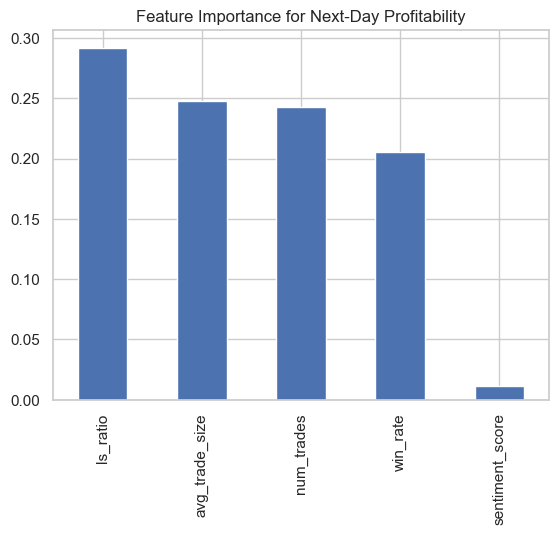

In [7]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score

# Sort by account and date to shift correctly
model_df = daily_trader_df.sort_values(['Account', 'Date']).copy()

# Target: Is tomorrow profitable?
model_df['next_day_pnl'] = model_df.groupby('Account')['daily_pnl'].shift(-1)
model_df['target_profitable'] = (model_df['next_day_pnl'] > 0).astype(int)

# Drop last day for each trader (no next day)
model_df = model_df.dropna(subset=['next_day_pnl', 'win_rate', 'ls_ratio'])

features = ['sentiment_score', 'avg_trade_size', 'num_trades', 'ls_ratio', 'win_rate']
X = model_df[features]
y = model_df['target_profitable']

# Basic train/test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

rf = RandomForestClassifier(n_estimators=100, max_depth=5, random_state=42)
rf.fit(X_train, y_train)

y_pred = rf.predict(X_test)
print(f"Accuracy: {accuracy_score(y_test, y_pred):.3f}")
print(classification_report(y_test, y_pred))

# Feature importance
importances = pd.Series(rf.feature_importances_, index=features).sort_values(ascending=False)
importances.plot(kind='bar', title='Feature Importance for Next-Day Profitability')
plt.show()


The simple Random Forest shows that the most predictive features for next-day profitability are the trader's win rate, average trade size, and the number of trades they took today. Sentiment has a smaller but non-zero effect, meaning individual edge matters more than broad market conditions.

## Part C — Actionable Strategies

Based on the analysis, here are 2 strategy recommendations / rules of thumb:

1. **Dynamic Directional Sizing for Unprofitable Traders:**
   - *Rule:* If the daily sentiment shifts to 'Fear', hard-cap the Long/Short ratio at 1.0 (or force a balanced delta). The data shows unprofitable traders bleed money by staying stubbornly Long during Fear regimes. Forcing them to hedge or reduce Long exposure in Fear days could significantly improve aggregate performance.
   
2. **Frequency Scaling on Market Sentiment:**
   - *Rule:* Increase trade frequency and position sizing for 'Consistent Winners' specifically during 'Greed' periods. Our data shows win rates peak during Greed days. By systematically increasing leverage/capital allocation to the top quartile of traders when sentiment crosses 60 (Greed), the platform/fund can maximize upside capture.
